<h2> Downloading and preparing our dataset </h2>

The function <b>load_medical_insurance</b> download the dataset from Kaggle and set up the folder datasets in our current project directory automatically. Then it load the downloaded dataset into a dataframe.

In [15]:
from pathlib import Path
import pandas as pd
import kagglehub
import shutil
def download_medical_insurance_csv():
    folder_path = Path("datasets/medical_insurance")
    csv_path = folder_path / "medical_insurance.csv"
    if not csv_path.is_file():
        print("Dataset not found, downloading from Kaggle...")
        folder_path.mkdir(parents=True, exist_ok=True)
        kaggle_folder_path = kagglehub.dataset_download("mirichoi0218/insurance")
        kaggle_csv_path = Path(kaggle_folder_path) / "insurance.csv"
        shutil.copy(kaggle_csv_path, csv_path)
        print("Download finished!")
    else:
        print("Dataset already exist, skipping download")
    return pd.read_csv(csv_path)
insurance_df = download_medical_insurance_csv()
insurance_df

Dataset already exist, skipping download


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Then for the purpose of demonstrating the data cleaning task of the project, we will purposely punch in some holes in the dataset with 1 quantitive columns <b>bmi</b> and 1 qualitative column <b>region</b>, the <b>random.seed</b> ensure that everytime we run this cell, the exact <b>5%</b> of the dataset got deleted (specifically the columns bmi and region)

In [16]:
import numpy as np

np.random.seed(67)

def make_data_ragged(insurance_df, ratio = 0.05):
    five_percent_cut = int(len(insurance_df) * ratio)
    np_bmi_cut = np.random.choice(insurance_df.index, five_percent_cut, replace = False)
    np_region_cut = np.random.choice(insurance_df.index, five_percent_cut, replace = False)
    insurance_df.loc[np_bmi_cut, 'bmi'] = np.nan
    insurance_df.loc[np_region_cut, 'region'] = np.nan

make_data_ragged(insurance_df)

Here is the number of <b>NULL</b> values of <b>each columns</b>

In [17]:
insurance_df.isnull().sum()

age          0
sex          0
bmi         66
children     0
smoker       0
region      66
charges      0
dtype: int64

A quick glance of the rows that got either their <b>bmi</b> or <b>region</b> deleted

In [18]:
insurance_df[insurance_df['bmi'].isna() | insurance_df['region'].isna()]

,age,sex,bmi,children,smoker,region,charges
6,46,female,33.440,1,no,NaN,8240.58960
21,30,female,32.400,1,no,NaN,4149.73600
31,18,female,26.315,0,no,NaN,2198.18985
33,63,male,NaN,0,no,northwest,13770.09790
38,35,male,36.670,1,yes,NaN,39774.27630
...,...,...,...,...,...,...,...
1301,62,male,30.875,3,yes,NaN,46718.16325
1302,25,female,NaN,1,no,southwest,3208.78700
1314,30,female,NaN,3,yes,northwest,18765.87545
1325,61,male,33.535,0,no,NaN,13143.33665


Save our ragged CSV

In [19]:
def create_ragged_csv():
    ragged_file_path = Path("datasets/medical_insurance/ragged_insurance.csv")
    insurance_df.to_csv(ragged_file_path, index=False)
    
create_ragged_csv()

<h2>Initial Data Visualization</h2>

Plot the <b>histogram</b> for bmi

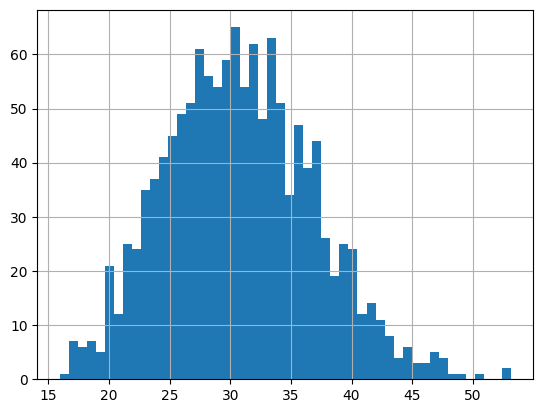

In [20]:
import matplotlib.pyplot as plt 
insurance_df['bmi'].hist(bins = 50)
plt.show()

We can see that the bmi distribution is lightly right tail skewed because of some outliers.
We then want to detect those outliers using <b>IQR method</b> 

In [21]:
def get_quantile_dict(df, column_name):
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75) 
    iqr = q3 - q1
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)
    quantile_dict = {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower": lower_fence, "Upper": upper_fence}
    return quantile_dict

quantile_dict = get_quantile_dict(insurance_df, "bmi") 
print(f"Q1: {quantile_dict['Q1']:.2f}") 
print(f"Q3: {quantile_dict['Q3']:.2f}")
print(f"IQR: {quantile_dict['IQR']:.2f}")
print(f"Lower Fence: {quantile_dict['Lower']:.2f}")
print(f"Upper Fence: {quantile_dict['Upper']:.2f}") 

Q1: 26.40
Q3: 34.80
IQR: 8.40
Lower Fence: 13.80
Upper Fence: 47.40


The fence is a range of distribution that if a value get out of it, it is an <b>outlier</b>. In this case the lower is 13.8 and the upper is ~47.3999

We can get the <b>rows</b> that has bmi as <b>outliers</b> here

In [22]:
outliers = insurance_df[(insurance_df['bmi'] < quantile_dict['Lower']) | (insurance_df['bmi'] > quantile_dict['Upper'])]
outliers

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520
860,37,female,47.60,2,yes,NaN,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820
1088,52,male,47.74,1,no,southeast,9748.91060
1317,18,male,53.13,0,no,southeast,1163.46270


In [23]:
print(f"There are {len(outliers)} outliers in the BMI column.")

There are 9 outliers in the BMI column.


We can visualize this using the <b>Box Plot</b>

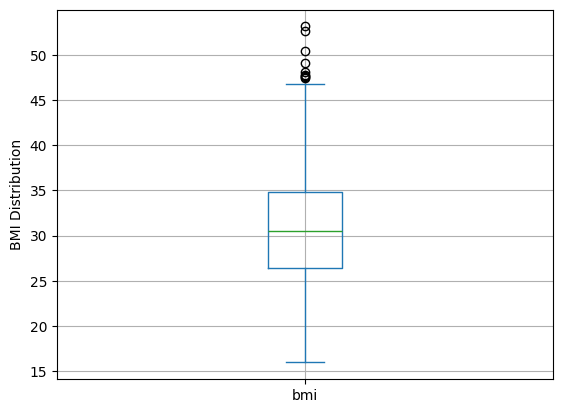

In [24]:
insurance_df['bmi'].plot(kind = 'box', grid = True)
plt.ylabel('BMI Distribution')
plt.show()

We can see the outliers outside of the upper fence. The outliers themselves is <b>not big enough to make a lot of difference</b>, and there are only <b>9</b> of them. so we decided to keep the outliers to ensure the accuracy of the statistic models that we intend to run. If we remove them or cap them then the models prediction for people who exceed the 47.8 BMI category would be <b>insufficient</b>.

The box plot above show the median position in the middle of the plot, which means that the distribution of the bmi is balanced on each side of the median, therefore we can <b>safely use the median to fill the bmi columns</b> in our dataset

In [25]:
bmi_median = insurance_df['bmi'].median() #30.5 is the median
insurance_df['bmi'] = insurance_df['bmi'].fillna(bmi_median)

For the qualitative column <b>region</b>, we can simply fill it using the value that has the most frequency

In [26]:
most_frequent_region = insurance_df['region'].mode()[0] #southeast is the most frequent region
insurance_df['region'] = insurance_df['region'].fillna(most_frequent_region)

We can <b>verify</b> if those empty values are handled

In [27]:
insurance_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There is no NULL value in any columns

Finally, lets save our <b>result</b>

In [28]:
clean_csv_path = Path("datasets/medical_insurance/clean_insurance_data.csv")
insurance_df.to_csv(clean_csv_path,index=False)

<h3>As the result, our data is cleaned!</h3>